In [1]:
import numpy as np
import pymc as pm
import arviz as az
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
conversions_A = 30
total_A = 100

conversions_B = 40
total_B = 100

In [4]:
with pm.Model() as ab_model:

    p_A = pm.Beta("p_A", alpha=1, beta=1)

    p_B = pm.Beta("p_B", alpha=1, beta=1)

    obs_A = pm.Binomial(
        "obs_A",
        n=total_A,
        p=p_A,
        observed=conversions_A
    )

    obs_B = pm.Binomial(
        "obs_B",
        n=total_B,
        p=p_B,
        observed=conversions_B
    )

    delta = pm.Deterministic(
        "delta",
        p_B - p_A
    )

    trace_ab = pm.sample(
        draws=3000,
        tune=2000,
        target_accept=0.95,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_A, p_B]


Output()

Sampling 4 chains for 2_000 tune and 3_000 draw iterations (8_000 + 12_000 draws total) took 1 seconds.


In [5]:
az.summary(
    trace_ab,
    var_names=["p_A", "p_B", "delta"]
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p_A,0.304,0.046,0.220,0.390,0.001,0.000,7417.0,6482.0,1.0
p_B,0.402,0.048,0.314,0.492,0.001,0.000,8640.0,7901.0,1.0
delta,0.099,0.067,-0.026,0.224,0.001,0.001,8185.0,7208.0,1.0


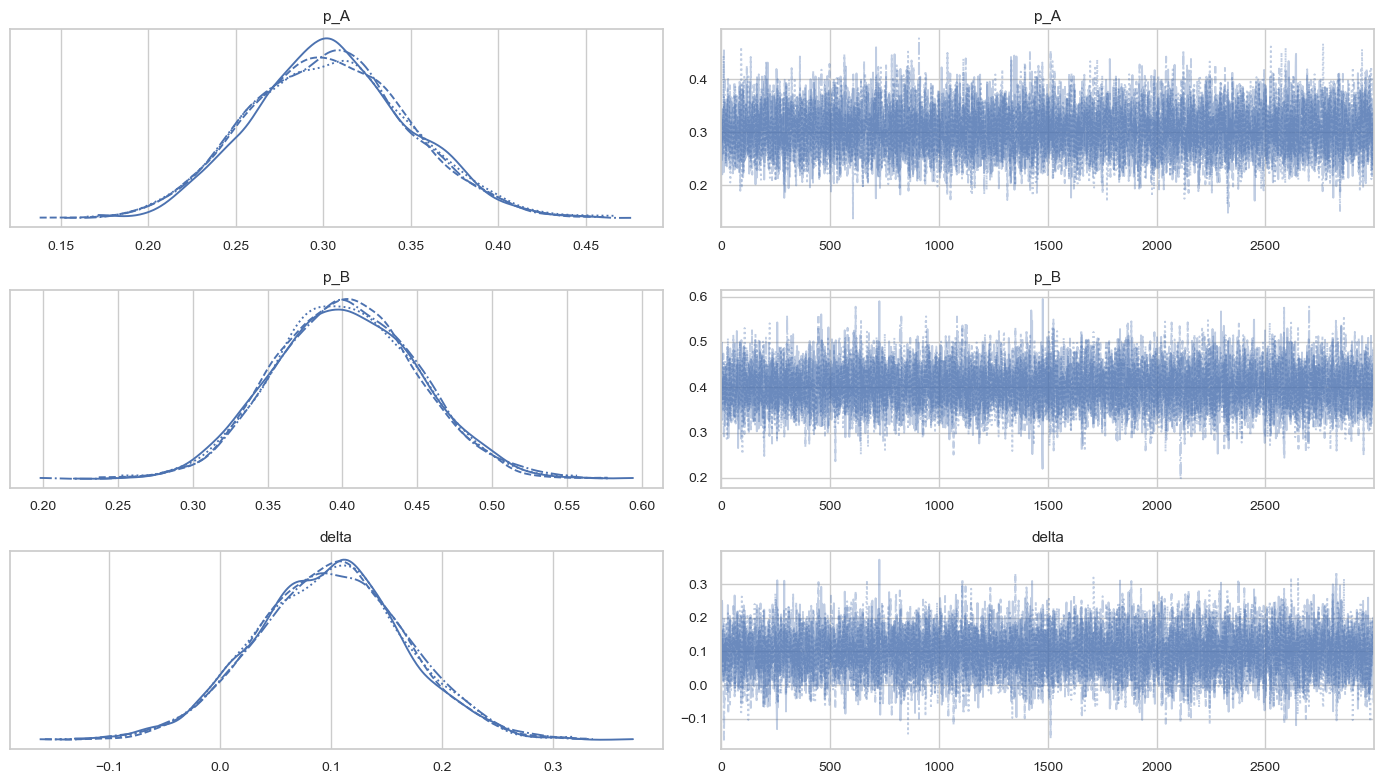

In [6]:
az.plot_trace(
    trace_ab,
    var_names=["p_A", "p_B", "delta"],
    figsize=(14, 8)
)

plt.tight_layout();

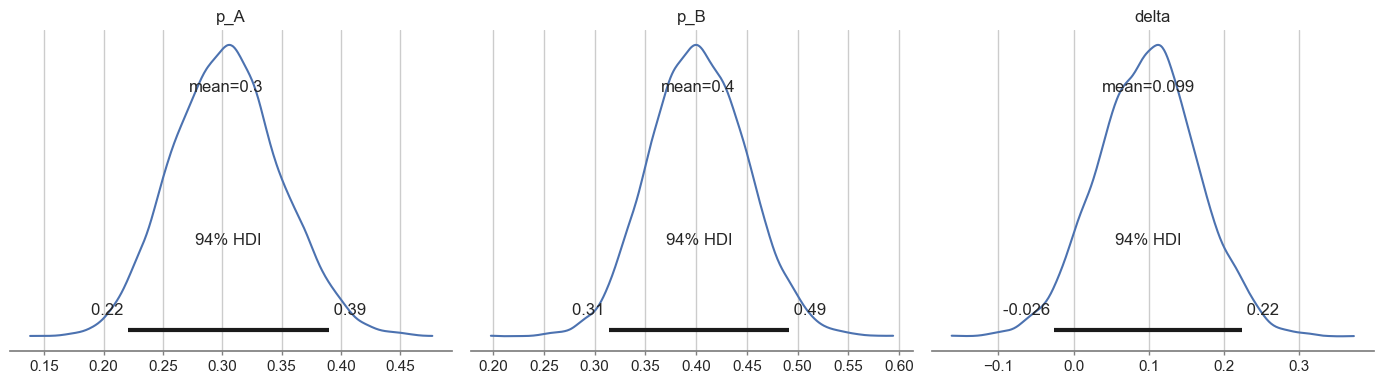

In [7]:
az.plot_posterior(
    trace_ab,
    var_names=["p_A", "p_B", "delta"],
    figsize=(14, 4)
)

plt.tight_layout();

In [8]:
delta_samples = (
    trace_ab.posterior["delta"]
    .stack(sample=("chain", "draw"))
    .values
)

prob_B_better = np.mean(delta_samples > 0)

print(f"P(B > A) = {prob_B_better:.3f}")

P(B > A) = 0.931


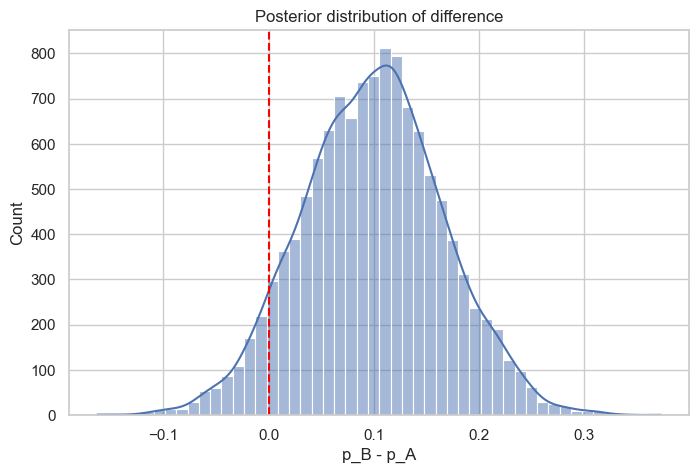

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(
    delta_samples,
    bins=50,
    kde=True
)

plt.axvline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("p_B - p_A")

plt.title("Posterior distribution of difference");